In [1]:
import os
import numpy as np
import cv2
import PIL
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import tensorflow_hub as hub

In [2]:
import tf_keras as tfk
IMAGE_SHAPE = (224, 224)
classifier = tfk.Sequential([
    hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/050-224-classification/2", input_shape=IMAGE_SHAPE+(3,))
])

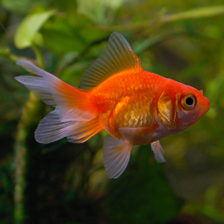

In [3]:
gold_fish = PIL.Image.open(r"D:\goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [4]:
gold_fish = np.array(gold_fish)
gold_fish = gold_fish/255
gold_fish

array([[[0.28235294, 0.33333333, 0.07058824],
        [0.31372549, 0.37254902, 0.09019608],
        [0.34901961, 0.41960784, 0.11764706],
        ...,
        [0.32941176, 0.39215686, 0.00392157],
        [0.32156863, 0.38431373, 0.00392157],
        [0.30980392, 0.36862745, 0.        ]],

       [[0.28627451, 0.33333333, 0.08235294],
        [0.3254902 , 0.38039216, 0.10980392],
        [0.35294118, 0.42352941, 0.12941176],
        ...,
        [0.32156863, 0.38039216, 0.00392157],
        [0.31372549, 0.37254902, 0.00392157],
        [0.30196078, 0.36078431, 0.        ]],

       [[0.28627451, 0.33333333, 0.08627451],
        [0.31372549, 0.36862745, 0.10196078],
        [0.34509804, 0.41568627, 0.12941176],
        ...,
        [0.31764706, 0.37647059, 0.00392157],
        [0.30980392, 0.36862745, 0.00784314],
        [0.29803922, 0.35686275, 0.00392157]],

       ...,

       [[0.05490196, 0.10980392, 0.01568627],
        [0.05098039, 0.11372549, 0.01960784],
        [0.05098039, 0

In [5]:
gold_fish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [6]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result

1/1 [==============================] - 1s 1s/step


array([[ 0.38737667,  5.1115646 , 11.536192  , ..., -0.9016145 ,
        -0.18741925,  0.19210535]], shape=(1, 1001), dtype=float32)

In [7]:
predicted_labels_index = np.argmax(result)
predicted_labels_index

np.int64(2)

In [8]:
image_labels = []
with open (r"D:\ImageNetLabels.txt") as f:
    image_labels = f.readlines()

In [9]:
image_labels[:5]

['background\n',
 'tench\n',
 'goldfish\n',
 'great white shark\n',
 'tiger shark\n']

In [10]:
image_labels[predicted_labels_index]

'goldfish\n'